In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd
import matplotlib.pyplot as plt

diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

print(diabetes.feature_names)
df.head()

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


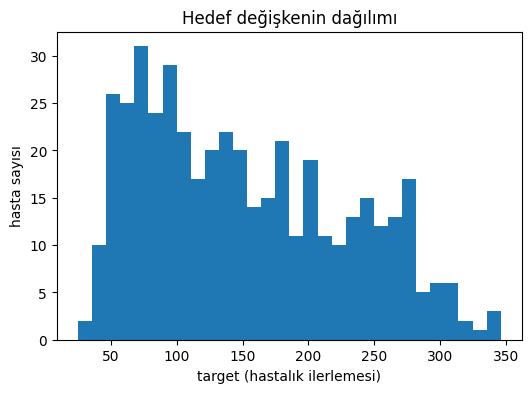

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df['target'], bins=30)
plt.xlabel('target (hastalık ilerlemesi)')
plt.ylabel('hasta sayısı')
plt.title('Hedef değişkenin dağılımı')
plt.show()

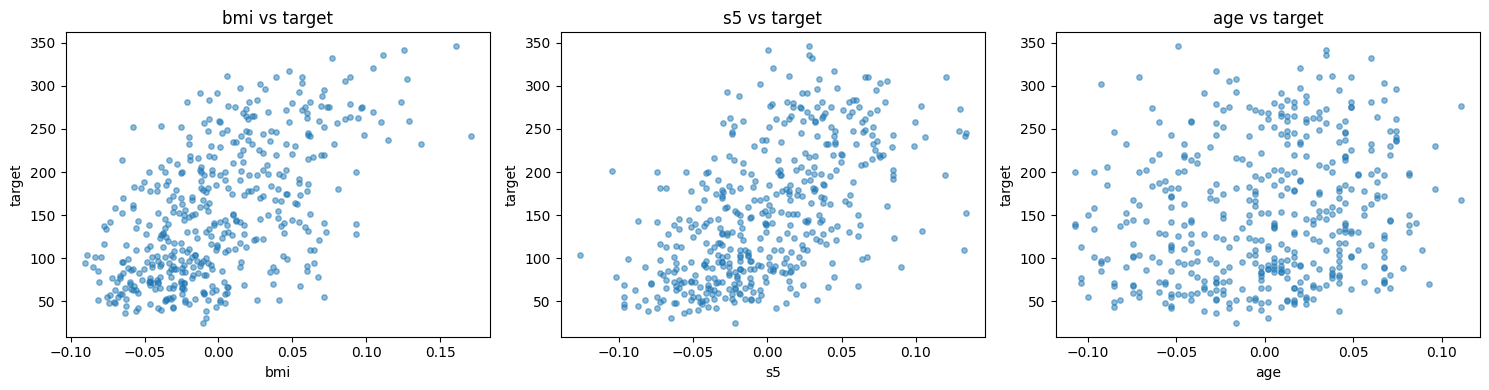

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat in zip(axes, ['bmi', 's5', 'age']):
    ax.scatter(df[feat], df['target'], alpha=0.5, s=15)
    ax.set_xlabel(feat)
    ax.set_ylabel('target')
    ax.set_title(f'{feat} vs target')

plt.tight_layout()
plt.show()

In [ ]:
df.corr()['target'].sort_values(ascending=False)

,target
target,1.000000
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[['bmi']]        # çift köşeli parantez — DataFrame olarak kalsın diye
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"R² = {r2_score(y_test, y_pred):.4f}")
print(f"Eğim = {model.coef_[0]:.2f}")
print(f"Kesişim = {model.intercept_:.2f}")

R² = 0.2803
Eğim = 988.42
Kesişim = 151.04


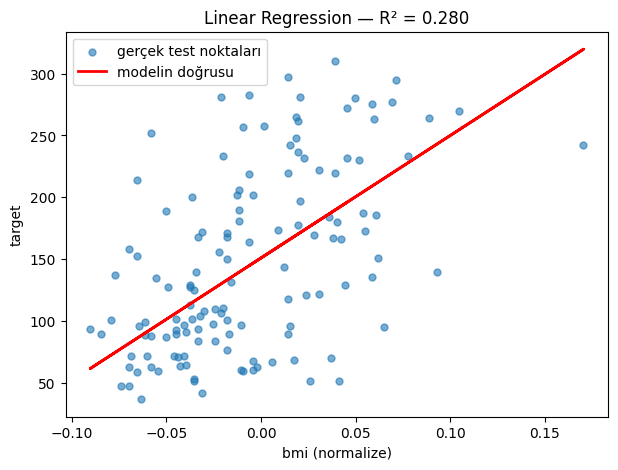

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(X_test, y_test, alpha=0.6, s=25, label='gerçek test noktaları')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='modelin doğrusu')
plt.xlabel('bmi (normalize)')
plt.ylabel('target')
plt.title(f'Linear Regression — R² = {r2_score(y_test, y_pred):.3f}')
plt.legend()
plt.show()

## Gözlemler

- Hedefin histogramı sağa çarpık: yığılma 50-150 arasında, 350'ye kadar uzanan
  bir kuyruk var. Simetrik değil. Ayrıca değerler 25'in altına inmiyor ama
  linear regression bunu bilmiyor — düz çizgi teorik olarak negatif tahmin
  üretebilir.
- Üç özelliği hedefe karşı çizdim: bmi ve s5'te yukarı yönlü bir eğilim var,
  age'de ise noktalar tamamen bulut gibi — her yaşta hem düşük hem yüksek
  target değeri var. Bu yüzden bmi ile modelledim.
- R² = 0.28. Yani BMI tek başına hedefteki değişkenliğin yaklaşık dörtte birini
  açıklıyor. Bu kötü bir sonuç değil — grafikte de eğilim gevşekti, aynı bmi
  değerinde target 50 de olabiliyordu 300 de.
- Kesişim 151.04 çıktı, bu neredeyse hedefin ortalaması (152.1). Sebebi
  özelliklerin ortalaması 0 olacak şekilde normalize edilmiş olması.
- Eğim 988 gibi devasa görünüyor ama aldatıcı: bmi normalize edilmiş, tüm
  aralığı -0.09 ile 0.17 arası. Gerçek anlamı, en düşük bmi'dan en yükseğine
  giderken tahminin ~257 puan artması. Katsayıyı yorumlayabilmek özelliğin
  biriminin anlamlı olmasına bağlıymış.